In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from scipy.stats import kruskal, mannwhitneyu, fisher_exact
from statannotations.Annotator import Annotator
import math
from functools import lru_cache
from itertools import combinations


In [2]:
data = pd.read_csv("data_linear/mmi_fit_sepa.tsv", sep='\t')

data

,#SampleID,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group,MMI_fit,mmibased
0,SRR23478195,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh,3.494657,mmihigh
1,SRR23478196,1,18.0,45.70,1.0,3.31,18.0,male,Control,Control(IT),50.83,mmilow,mmilow,mmilow,3.494657,mmilow
2,SRR23478197,2,18.0,39.73,1.0,2.81,18.0,female,Control,Control(IT),50.83,mmilow,mmilow,mmilow,3.494657,mmilow
3,SRR23478198,3,30.0,57.06,2.0,4.25,30.0,male,Control,Control(IT),56.42,mmihigh,mmihigh,mmihigh,4.367484,mmilow
4,SRR23478199,4,30.0,56.14,2.0,4.18,30.0,male,Control,Control(IT),56.42,mmilow,mmilow,mmilow,4.367484,mmilow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,SRR23492553,138,186.0,69.30,15.0,5.28,186.0,NaN,UC,PIBD(IT),122.46,mmilow,ulcerative colitis,UC,NaN,PIBD
139,SRR23492554,139,66.0,62.22,5.0,4.68,66.0,NaN,UC,PIBD(IT),93.28,mmilow,ulcerative colitis,UC,NaN,PIBD
140,SRR23492555,140,150.0,55.53,12.0,4.13,150.0,NaN,UC,PIBD(IT),108.56,mmilow,ulcerative colitis,UC,NaN,PIBD
141,SRR23492556,141,42.0,84.98,3.0,6.58,42.0,NaN,UC,PIBD(IT),74.80,mmihigh,ulcerative colitis,UC,NaN,PIBD


In [3]:
control = data.loc[data["Host_disease"] == "Control"]

con_mmi = control["mmi"].tolist()
con_age = control["real_age"].tolist()

con_residual = np.mean(np.array(con_age) - np.array(con_mmi)).round(2)
print(con_residual) ## (Age - MMI) mean value, Not usuable

1.69


In [10]:
disease = data.loc[data["Host_disease"] != "Control"]

print(disease.count()[:1])

#SampleID    49
dtype: int64


In [11]:
dis_age = disease["real_age"].tolist()
dis_mmi = disease["mmi"].tolist()

dis = np.mean(np.array(dis_age) - np.array(dis_mmi)).round(2)
print(dis) ## (Age - MMI) mean value, Not usuable

70.76


## MMI age mean calculate

In [12]:
control.head(2)

,#SampleID,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group,MMI_fit,mmibased
0,SRR23478195,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh,3.494657,mmihigh
1,SRR23478196,1,18.0,45.70,1.0,3.31,18.0,male,Control,Control(IT),50.83,mmilow,mmilow,mmilow,3.494657,mmilow


In [13]:
high = control[control['mmibased'] == "mmihigh"].copy() ## mmibased column showed fitting-based separation
low = control[control['mmibased'] == 'mmilow'].copy()

dfs = [high, low]

for df in dfs:
    df["age"] = (df["real_age"] / 12) - 0.5
    df['mmi_y'] = (df['mmi'] / 12) - 0.5

high = high.round(2)
low = low.round(2)


In [14]:
high.head(2)

,#SampleID,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group,MMI_fit,mmibased,age,mmi_y
0,SRR23478195,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh,3.49,mmihigh,1.0,5.09
9,SRR23478205,9,30.0,67.78,2.0,5.15,30.0,male,Control,Control(IT),56.42,mmihigh,mmihigh,mmihigh,4.37,mmihigh,2.0,5.15


In [15]:
dfs = {"high": high, "low": low}


rows1 = []

for name, df in dfs.items():
    count = df["#SampleID"].count()
    mean = df["age"].mean()
    std = df["age"].std()
    sex = df["host_sex"].value_counts(dropna=False)
    mean_mmi = df["mmi_y"].mean()
    std_mmi = df["mmi_y"].std()

    
    rows1.append({
        "Group": name,
        "n": count,
        "age": f"{mean:.2f} ({std:.2f})",
        "Sex": sex.to_dict(),
        "mean mmi": f"{mean_mmi:.2f} ({std_mmi:.2f})"
    })

table2 = pd.DataFrame(rows1)


table2

,Group,n,age,Sex,mean mmi
0,high,51,8.06 (3.95),"{'female': 29, 'male': 22}",8.95 (1.72)
1,low,43,6.84 (4.38),"{'male': 26, 'female': 17}",5.48 (2.14)


In [22]:
age_u, age_p = mannwhitneyu(
    high['age'].dropna(),
    low['age'].dropna(),
    alternative="two-sided"
)


mmi_u, mmi_p = mannwhitneyu(
    high['mmi_y'].dropna(),
    low['mmi_y'].dropna(),
    alternative="two-sided"
)

print(f"age: {age_u}, {age_p.round(2)}") # non-significant
print(f"mmi: {mmi_u}, {mmi_p.round(10)}") # p<0.001

age: 1280.5, 0.16
mmi: 1948.5, 1e-10


In [23]:
high.head(2)

,#SampleID,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group,MMI_fit,mmibased,age,mmi_y
0,SRR23478195,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh,3.49,mmihigh,1.0,5.09
9,SRR23478205,9,30.0,67.78,2.0,5.15,30.0,male,Control,Control(IT),56.42,mmihigh,mmihigh,mmihigh,4.37,mmihigh,2.0,5.15


In [24]:
sex_table = np.array([
    [29, 22],   # MMI-high
    [26, 17]    # MMI-low
])

# Fisher's exact test
odds_ratio, p_value = fisher_exact(
    sex_table,
    alternative="two-sided"
)

print("Odds ratio :", odds_ratio)
print("P-value    :", p_value.round(2))

Odds ratio : 0.8618881118881119
P-value    : 0.83


| Host factors | MMI high | MMI low | Statistical test(p-value) |
|--------------|----------|---------|---------------------------|
| Count        | 51       | 43      |                           |
| Age(Mean (SD)) | 8.06 (±3.95) | 6.84(±4.38) | 0.16(Mann-Whitney U test)           |
| MMI(Mean (SD)) | 8.95 (±1.72) | 5.48 (±2.14) | 1e-10(Mann-Whitney U test)       |
| Sex            |               |               | 0.83(Fisher's exact test)         |
| Male           | 29            | 22            |              |
| Female         | 26            | 17            |              |

### PIBD patients

In [25]:
pibd = data[data['Host_disease'] != "Control"].copy()

cd = pibd[pibd['Group'] == "CD"].copy()
uc = pibd[pibd['Group'] == 'UC'].copy()

dfs = [cd, uc, pibd]

for df in dfs:
    df["age"] = (df["real_age"] / 12) - 0.5
    df['mmi_y'] = (df['mmi'] / 12) - 0.5

pibd = pibd.round(2)
cd = cd.round(2)
uc = uc.round(2)

In [26]:
rows1 = []

dfs = {"high": high, "low": low, "pibd": pibd}

for name, df in dfs.items():
    count = df["#SampleID"].count()
    mean = df["age"].mean()
    std = df["age"].std()
    sex = df["host_sex"].value_counts(dropna=False)
    mean_mmi = df["mmi_y"].mean()
    std_mmi = df["mmi_y"].std()

    
    rows1.append({
        "Group": name,
        "n": count,
        "age": f"{mean:.2f} ({std:.2f})",
        "Sex": sex.to_dict(),
        "mean mmi": f"{mean_mmi:.2f} ({std_mmi:.2f})"
    })

table3 = pd.DataFrame(rows1)

In [27]:
table3

,Group,n,age,Sex,mean mmi
0,high,51,8.06 (3.95),"{'female': 29, 'male': 22}",8.95 (1.72)
1,low,43,6.84 (4.38),"{'male': 26, 'female': 17}",5.48 (2.14)
2,pibd,49,11.90 (4.05),"{nan: 26, 'female': 14, 'male': 9}",6.00 (1.91)


In [ ]:
table3.to_csv("data_linear/3-results/1_statistical/mmi_group_statistical.csv", sep=',')

### PIBD statistical

In [28]:
def pairwise_mannwhitneyu(

    dfs,
    columns=["age", "mmi_y"],
    alternative="two-sided"
):

    rows = []

    for (group1, df1), (group2, df2) in combinations(dfs.items(), 2):
        row = {
            "comparison": f"{group1} vs {group2}",
            "group1": group1,
            "group2": group2
        }

        for col in columns:
            x = df1[col].dropna()
            y = df2[col].dropna()
            u_stat, p_val = mannwhitneyu(
                x,
                y,
                alternative=alternative
            )

            row[f"{col}_n1"] = len(x)
            row[f"{col}_n2"] = len(y)
            row[f"{col}_U"] = u_stat
            row[f"{col}_p"] = p_val
        rows.append(row)

    return pd.DataFrame(rows)

In [33]:
dfs = {
    "high": high,
    "low": low,
    "PIBD": pibd
}

result_df = pairwise_mannwhitneyu(
    dfs=dfs,
    columns=["age", "mmi_y"]
)

result_df

,comparison,group1,group2,age_n1,age_n2,age_U,age_p,mmi_y_n1,mmi_y_n2,mmi_y_U,mmi_y_p
0,high vs low,high,low,51,43,1280.5,1.622568e-01,51,43,1948.5,1.029407e-10
1,high vs PIBD,high,PIBD,51,49,592.5,5.614140e-06,51,49,2156.0,4.179252e-10
2,low vs PIBD,low,PIBD,43,49,412.5,4.938989e-07,43,49,877.5,1.696179e-01


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>comparison</th>
      <th>group1</th>
      <th>group2</th>
      <th>age_n1</th>
      <th>age_n2</th>
      <th>age_U</th>
      <th>age_p</th>
      <th>mmi_y_n1</th>
      <th>mmi_y_n2</th>
      <th>mmi_y_U</th>
      <th>mmi_y_p</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>high vs low</td>
      <td>high</td>
      <td>low</td>
      <td>51</td>
      <td>43</td>
      <td>1280.5</td>
      <td>1.622568e-01</td>
      <td>51</td>
      <td>43</td>
      <td>1948.5</td>
      <td>1.029407e-10</td>
    </tr>
    <tr>
      <th>1</th>
      <td>high vs PIBD</td>
      <td>high</td>
      <td>PIBD</td>
      <td>51</td>
      <td>49</td>
      <td>592.5</td>
      <td>5.614140e-06</td>
      <td>51</td>
      <td>49</td>
      <td>2156.0</td>
      <td>4.179252e-10</td>
    </tr>
    <tr>
      <th>2</th>
      <td>low vs PIBD</td>
      <td>low</td>
      <td>PIBD</td>
      <td>43</td>
      <td>49</td>
      <td>412.5</td>
      <td>4.938989e-07</td>
      <td>43</td>
      <td>49</td>
      <td>877.5</td>
      <td>1.696179e-01</td>
    </tr>
  </tbody>
</table>
</div>

- High vs low
    - age p_val = 1.62e-1, non-significant
    - mmi p_val = 1.03e-10, p<0.001
- High vs pibd
    - age p_val = 5.61e-6 p<0.001
    - mmi p_val = 4.18e-10 p<0.001
- Low VS pibd
    - age p_val = 4.94e-7 p<0.001
    - mmi p_val = 1.69e-1 non-significant

## Plot

/tmp/ipykernel_3868995/3655096971.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged,x="mmibased",y="mmi_y",order=order,width=0.6,showfliers=False, palette=color)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

mmihigh vs. mmilow: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.029e-10 U_stat=1.948e+03
mmilow vs. PIBD: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.696e-01 U_stat=8.775e+02
mmihigh vs. PIBD: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.179e-10 U_stat=2.156e+03


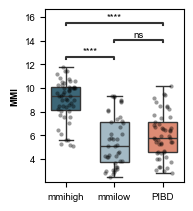

In [ ]:
## Linear separation group compare

merged = pd.concat([high, low, pibd], axis=0, ignore_index=True)

order = ["mmihigh", "mmilow", "PIBD"]

color = {
    "mmihigh":"#326a81a0",
    "mmilow":"#9fbccaa0",
    "PIBD":"#ef8162"
}

plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
# affects whiskers, medians, caps (all Line2D)
plt.rcParams['lines.linewidth'] = 0.6

fig = plt.figure(figsize=(2.75, 2.25))
ax = fig.add_subplot(111)

sns.boxplot(data=merged,x="mmibased",y="mmi_y",order=order,width=0.6,showfliers=False, palette=color)

sns.stripplot(data=merged,x="mmibased",y="mmi_y",order=order,color="black",alpha=0.4,jitter=0.2,size=3)

pairs = [
    ("mmihigh", "mmilow"),
    ("mmihigh", "PIBD"),
    ("mmilow", "PIBD")
]

annot = Annotator(ax,pairs,data=merged,x="mmibased",y="mmi_y",order=order)
annot.configure(test="Mann-Whitney",text_format="star",comparisons_correction="BH",loc="inside")
ax.set_ylabel("MMI", fontweight='bold')
ax.set_xlabel("")
ax.set_box_aspect(1.25)


annot.apply_and_annotate()

fig.savefig('figure_linear/2_separation/group_mmi.pdf', dpi=300)